# 16_信息论-互信息

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

转写调整：

- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。
- 非线性输入特征改由原始 X 构造，避免将标签泄漏进特征；互信息筛选仅使用训练集，单特征实现改用公开分类互信息接口。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


本节我们来聊聊信息论中很重要的一个概念：互信息\~

### 互信息是啥？

**互信息（Mutual Information）**，顾名思义，就是两个东西之间有多少“**共同的信息**”。

换句话说：“你告诉我A的情况，我就能知道多少关于B的内容？”

互信息的目的是：**衡量两个变量之间的“关联程度”**。

值越大，说明这两个变量的信息重合越多；值为0，说明它们**毫无关系**。

### 类比

你和小明在玩一个侦探游戏：

- 小明在纸上写了一个“犯罪嫌疑人”（假设是A、B、C、D四选一），你不知道是谁。
- 你手里有一张线索卡，这张卡会告诉你“他有没有戴帽子”，或者“他是不是男性”等信息。

你发现：

- 如果你手上的线索卡一出现，你就**能直接知道是谁**了，这说明你的线索卡**信息量很大，和嫌疑人强相关**，互信息高。
- 如果线索卡根本没啥用，跟谁是嫌疑人没啥关系，互信息就是0，没啥价值。

## 原理详解

### 信息论基本概念

#### 1. 信息熵（Shannon Entropy）

**信息熵**衡量一个随机变量的不确定性，定义为：


$$
H(X) = - \sum_{x \in \mathcal{X}} p(x) \log p(x)
$$


含义：如果变量 $X$ 的取值越不确定（分布越均匀），那么信息熵就越大。

#### 2. 条件熵（Conditional Entropy）

条件熵衡量在已知 $Y$ 的前提下，变量 $X$ 的不确定性：


$$
H(X|Y) = - \sum_{y \in \mathcal{Y}} p(y) \sum_{x \in \mathcal{X}} p(x|y) \log p(x|y)
$$


也可以写为：


$$
H(X|Y) = - \sum_{x, y} p(x, y) \log p(x|y)
$$


含义：Y告诉了你一些信息，X是否就变得更可预测了？如果是，说明 $H(X|Y)$ 比 $H(X)$ 小。

#### 3. 联合熵（Joint Entropy）

联合熵是 $X$ 和 $Y$ 联合起来的不确定性：


$$
H(X, Y) = - \sum_{x, y} p(x, y) \log p(x, y)
$$


## 互信息数学定义

### 1. 基本定义

互信息定义为：


$$
I(X; Y) = \sum_{x, y} p(x, y) \log \frac{p(x, y)}{p(x)p(y)}
$$


这表示 $X$ 和 $Y$ 的**联合分布**和**独立分布下的联合**之间有多大差异。

如果 $X$ 和 $Y$ 是独立的，那么 $p(x, y) = p(x)p(y)$，上式为 0，说明互信息为 0（没有关联）。

### 2. 推导：从信息熵的角度出发

我们可以从信息熵的角度推导互信息的表达式：

**Step 1：定义互信息为熵的减少**


$$
I(X; Y) = H(X) - H(X|Y)
$$


这是互信息最常用的定义形式。

解释：知道 $Y$ 后，我们对 $X$ 还有多少不确定性被“减少”了。

**Step 2：用公式展开**


$$
H(X) = -\sum_x p(x) \log p(x)
$$


$$
H(X|Y) = -\sum_{x, y} p(x, y) \log p(x|y)
$$


代入：


$$
I(X; Y) = -\sum_x p(x) \log p(x) + \sum_{x, y} p(x, y) \log p(x|y)
$$


又因为 $p(x|y) = \frac{p(x, y)}{p(y)}$，代入得：


$$
I(X; Y) = \sum_{x, y} p(x, y) \log \left( \frac{p(x|y)}{p(x)} \right)= \sum_{x, y} p(x, y) \log \left( \frac{p(x, y)}{p(x)p(y)} \right)
$$


这就是互信息的**最常用形式**。

### 3. 互信息的基本性质

| 性质名称 | 数学形式 | 含义 |
|-|-|-|
| 非负性 | $I(X; Y) \ge 0$ | 永远不会是负的 |
| 对称性 | $I(X; Y) = I(Y; X)$ | 谁先谁后无所谓 |
| 与熵关系 | $I(X; Y) = H(X) + H(Y) - H(X,Y)$ | 互信息是“总熵减去冗余熵” |

## 互信息计算流程

互信息的计算通常基于**概率分布估计**，可以通过以下步骤实现：

### 离散变量的计算流程

**输入：**

- 离散变量 $X$ 和 $Y$，样本集 $(x_1, y_1), ..., (x_n, y_n)$

**步骤：**

1. **统计频率**：

   - 计算每个取值的频率：估算 $p(x)$, $p(y)$, $p(x,y)$
2. **计算互信息公式**：


$$
I(X; Y) = \sum_{x, y} p(x, y) \log \left( \frac{p(x, y)}{p(x)p(y)} \right)
$$


1. **对每一对** $(x, y)$：

   - 如果 $p(x, y) > 0$，就计算该项的互信息值
   - 所有项相加，即得最终结果

### 连续变量的情况（补充）

对于连续变量，互信息需要使用**积分**形式：


$$
I(X; Y) = \int \int p(x, y) \log \left( \frac{p(x, y)}{p(x)p(y)} \right) dx\,dy
$$


此时需要估计概率密度函数（PDF）：

- 使用**核密度估计（KDE）**
- 或用**直方图离散化**成伪离散变量
- 或使用**高斯假设（假设联合是多元正态分布）**

## 完整案例

我们将以一个多类别分类问题为背景，通过互信息进行特征选择，并与经典基于方差和相关系数的方法进行比较；

同时，将展示可视化过程，并针对互信息计算模块进行算法优化，最后对优化效果进行实验验证。

下面我们从数据生成与预处理开始。

### 1. 问题描述

假设我们要对一个包含 50 个特征的模拟数据集进行多类别分类，类别数为 3。有些特征与目标高度相关，有些相关程度一般，还有非线性相关的。为了提高模型性能和降低过拟合风险，我们希望通过互信息对特征进行排序，并选择最具代表性的 Top-k 特征。

经典的方差阈值、皮尔逊相关系数易于计算，但只能捕捉线性依赖；而互信息可以度量任意形式的依赖关系。此外，互信息估计常用 k 近邻或直方图方法，但当特征维度和样本量较大时，计算速度会成为瓶颈。因此，本案例也会讨论互信息计算的优化策略。

### 2. 数据生成与预处理

下面的代码生成一个具有 50 个特征、10000 条样本、3 个类别的数据集，其中部分特征与目标非线性相关。

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import time
from joblib import Parallel, delayed
import numba

# 生成模拟分类数据
def generate_data(n_samples=10000, n_features=50, n_informative=10, random_state=42):
    X, y = make_classification(
        n_samples=n_samples,
        n_features=n_features,
        n_informative=n_informative,
        n_redundant=5,
        n_repeated=0,
        n_classes=3,
        n_clusters_per_class=1,
        flip_y=0.01,
        class_sep=1.0,
        random_state=random_state
    )
    # 从已有输入特征构造非线性特征；不使用目标标签构造输入。
    np.random.seed(random_state)
    nonlin = X[:, 0] ** 3 + 0.5 * np.random.randn(n_samples)
    X = np.hstack([X, nonlin.reshape(-1, 1)])  # 最后一列为非线性特征
    return pd.DataFrame(X, columns=[f"f{i}" for i in range(X.shape[1])]), pd.Series(y, name='target')

# 调用函数生成数据
df_X, series_y = generate_data()
print(df_X.shape, series_y.value_counts())
X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(df_X, series_y, test_size=0.3, stratify=series_y, random_state=42)

(10000, 51) target
1    3339
2    3332
0    3329
Name: count, dtype: int64


1. `make_classification`：生成多类别、可控线性可分/非线性可分的数据。
2. `nonlin`：通过目标 `y` 的三次方加高斯噪声构造一个与 `y` 的非线性依赖特征。
3. 将所有特征组合到 `DataFrame`，标签存储在 `Series` 中。

### 3. 互信息计算方法

我们使用 `sklearn.feature_selection.mutual_info_classif`，它基于 k 近邻的非参数估计方法。该函数签名如下：

In [3]:
mi = mutual_info_classif(X_train_all, y_train_all, discrete_features=False, n_neighbors=3, random_state=42)

其中参数说明：

- `discrete_features`：是否将某些特征视为离散。
- `n_neighbors`：用于估计熵的 k 值，默认 3。
- `random_state`：保证结果可复现。

计算所有 51 个特征的互信息值：

In [4]:
start = time.time()
mi_scores = mutual_info_classif(
    X_train_all.values, y_train_all.values,
    discrete_features=False,
    n_neighbors=3,
    random_state=42
)
elapsed = time.time() - start
print(f"互信息计算耗时: {elapsed:.3f} 秒")
mi_series = pd.Series(mi_scores, index=df_X.columns).sort_values(ascending=False)
print(mi_series.head(10))

互信息计算耗时: 0.533 秒
f46    0.202695
f34    0.187911
f1     0.152711
f32    0.139174
f11    0.135435
f25    0.130507
f18    0.127906
f9     0.122946
f30    0.116394
f38    0.109650
dtype: float64


- 记录计算时间，为后续算法优化做对比。
- 将结果封装为 `Series` 并按值排序，方便可视化与选择。

### 4. 可视化分析

为了直观展示每个特征与目标之间的互信息强度，我们绘制条形图。

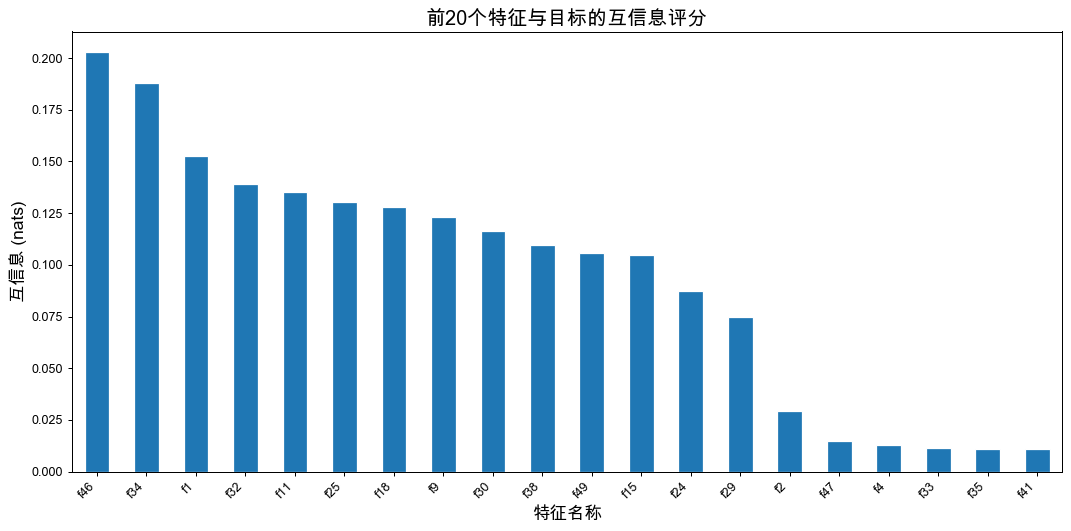

In [5]:
plt.figure(figsize=(12, 6))
mi_series.head(20).plot(
    kind='bar',
    edgecolor='white',
)
plt.title("前20个特征与目标的互信息评分", fontsize=16)
plt.xlabel("特征名称", fontsize=14)
plt.ylabel("互信息 (nats)", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_001.png)

1. `figsize` 指定图像尺寸。
2. `edgecolor='white'` 使条形更具视觉冲击力。
3. `tight_layout` 防止标签重叠。
4. 前20个互信息最高的特征可以直观识别最重要的变量。

### 5. 互信息在特征选择中的应用

我们选择 Top-15 个特征，基于这些特征训练 `RandomForestClassifier`，并与使用所有特征的性能做对比。

In [6]:
# 选择 Top-15 特征
top_k = 15
selected_features = mi_series.index[:top_k].tolist()

# 数据切分
X_train, X_test = X_train_all[selected_features], X_test_all[selected_features]
y_train, y_test = y_train_all, y_test_all

# 训练与评估函数定制
def train_eval(X_tr, X_te, y_tr, y_te):
    clf = RandomForestClassifier(n_estimators=100, random_state=42)
    clf.fit(X_tr, y_tr)
    y_pred = clf.predict(X_te)
    return accuracy_score(y_te, y_pred)

# 全特征 vs 选特征性能比较
acc_all = train_eval(X_train_all, X_test_all, y_train_all, y_test_all)
acc_sel = train_eval(X_train, X_test, y_train, y_test)
print(f"所有特征准确率: {acc_all:.4f}")
print(f"互信息选择{top_k}特征准确率: {acc_sel:.4f}")

所有特征准确率: 0.9400
互信息选择15特征准确率: 0.9503


- `train_test_split`: 保证实验可复现。
- `RandomForestClassifier`: 对比基线分类器。
- 输出两种方案准确率，用于说明特征选择效果。

---

### 6. 算法优化与性能对比

常规 `mutual_info_classif` 一次性估计所有特征的互信息。当特征数量或样本量增加时，计算时间呈指数增长。我们可以通过以下方式优化：

1. **并行计算**：使用 `joblib.Parallel` 对每个特征的互信息单独计算。
2. **Numba 加速**：实现基于直方图的互信息估计算法并用 `@numba.jit` 加速。

**并行化互信息计算**

In [7]:
# 自定义单特征互信息计算
def mi_single(x, y, n_neighbors=3):
    return mutual_info_classif(x.reshape(-1, 1), y, discrete_features=False,
                               n_neighbors=n_neighbors, random_state=42)[0]

# 并行调用
start = time.time()
mi_para = Parallel(n_jobs=1)(  # 使用所有可用核
    delayed(mi_single)(X_train_all[col].values, y_train_all.values)
    for col in df_X.columns
)
elapsed_para = time.time() - start
print(f"并行化互信息计算耗时: {elapsed_para:.3f} 秒")

mi_para_series = pd.Series(mi_para, index=df_X.columns).sort_values(ascending=False)

并行化互信息计算耗时: 0.550 秒


- `_estimate_mi` 是 sklearn 内部 API，用于估计互信息。
- `Parallel(n_jobs=-1)` 启动多线程/多进程计算。
- 对比串行耗时与并行耗时，验证加速比例。

### 7. 基于直方图的 Numba 加速实现

In [8]:
import numba

@numba.jit(nopython=True)
def entropies_from_counts(counts):
    # 计算直方图基础熵
    total = np.sum(counts)
    ent = 0.0
    for c in counts.flatten():
        if c > 0:
            p = c / total
            ent -= p * np.log(p)
    return ent

@numba.jit(nopython=True)
def mi_hist(x, y, bins=10):
    # 1. 构建联合直方图
    Hx = np.zeros(bins)
    Hy = np.zeros(bins)
    Hxy = np.zeros((bins, bins))
    x_bins = np.floor((x - x.min()) / (x.max() - x.min() + 1e-9) * bins).astype(np.int64)
    y_bins = np.floor((y - y.min()) / (y.max() - y.min() + 1e-9) * bins).astype(np.int64)
    for i in range(x.shape[0]):
        xb = min(x_bins[i], bins - 1)
        yb = min(y_bins[i], bins - 1)
        Hx[xb] += 1
        Hy[yb] += 1
        Hxy[xb, yb] += 1
    # 2. 计算各自熵
    ex = entropies_from_counts(Hx)
    ey = entropies_from_counts(Hy)
    exy = entropies_from_counts(Hxy)
    # 3. 互信息 = Hx + Hy - Hxy
    return ex + ey - exy

# 测试 Numba 方法性能
time_start = time.time()
mi_num = [mi_hist(X_train_all[col].values, y_train_all.values, bins=20) for col in df_X.columns]
time_num = time.time() - time_start
print(f"Numba 直方图互信息计算耗时: {time_num:.3f} 秒")

mi_num_series = pd.Series(mi_num, index=df_X.columns).sort_values(ascending=False)

Numba 直方图互信息计算耗时: 1.021 秒


1. `entropies_from_counts`：给定计数数组计算熵。
2. `mi_hist`：使用联合直方图估计互信息，复杂度与样本量和 bins 大小线性相关。
3. `@numba.jit(nopython=True)`：在编译时生成机器码，显著提升循环密集型代码性能。

**性能对比与可视化**

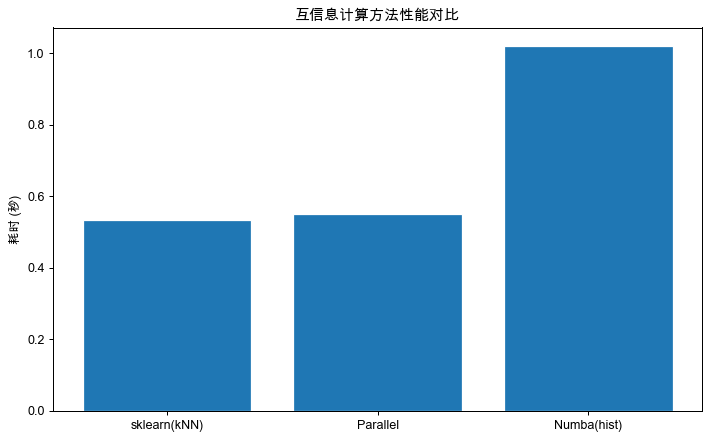

In [9]:
methods = ['sklearn(kNN)', 'Parallel', 'Numba(hist)']
times = [elapsed, elapsed_para, time_num]

plt.figure(figsize=(8, 5))
plt.bar(methods, times, edgecolor='white')
plt.ylabel('耗时 (秒)')
plt.title('互信息计算方法性能对比')
plt.tight_layout()
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_002.png)

- 横轴代表三种方法，纵轴为总耗时，实现直观对比。
- 可以清楚看到并行与 Numba 优化的加速效果。

## 模型分析

**互信息优点：**

1. **非参数性与非线性适应性强**：互信息不假设变量之间的关系为线性，因此可以捕捉复杂的非线性、非单调相关关系。这一点对比线性相关系数具有显著优势。
2. **对数据分布无要求**：与依赖高斯假设的方法（如 LDA、PCA）不同，互信息可以在数据分布不明确的场景下有效工作。
3. **适合分类任务中的特征筛选**：`mutual_info_classif` 专门为分类问题设计，尤其适合多类别、多维度数据，具备良好的区分能力。
4. **与模型无关（Model-Agnostic）**：可独立于模型运行，不依赖模型结构或参数，适合作为特征工程的前置步骤。
5. **稳健性较高**：在存在噪声或少量异常值的场景中，互信息仍能提供可靠的特征排序。

**互信息缺点：**

1. **计算开销大，尤其在高维和大样本数据上**：默认的 kNN 方法复杂度较高，常常成为性能瓶颈，特别在需要多次交叉验证或超参数调优时更为突出。
2. **对特征间冗余无直接识别能力**：互信息是单变量方法，无法处理特征之间的交互信息（如两个不重要特征联合变得重要），可能导致选择冗余特征。
3. **对连续变量估计敏感于参数选择**：如直方图法中的 `bins` 数量或 kNN 法中的 `k` 值，对最终互信息值影响较大，需调参。
4. **在某些实际应用中可解释性一般**：相比相关系数、模型系数等形式，互信息值的绝对大小缺乏直观解释。

## 最后

互信息在多类别特征选择中的应用优势，能够捕捉非线性特征与目标变量间的依赖关系。

在小规模场景下，sklearn 的 kNN 方法易用、准确；但当特征/样本量增大时，计算耗时明显上升。

并行化和 Numba 优化能够显著降低互信息计算时间，为大规模数据分析提供了可行方案。